In [39]:
import cv2
import os

img_dir = '../Croptimal/resnet/train'

class_subdirs = [
    # Class 0
    # (subdir, weight)
    [('256_class_0', 1.0)],
    # Class 1
    [('256_class_1', 1.0)]]

n_classes = len(class_subdirs)
global_imgs = []

for i, class_data in enumerate(class_subdirs):
    global_imgs.append([])
    for subdir, weight in class_data:
        class_path = os.path.join(img_dir, subdir)
        for img_file in os.listdir(class_path):
            if img_file.endswith(('.jpg', '.jpeg', '.png', '.bmp')):
                img_path = os.path.join(class_path, img_file)
                img = cv2.imread(img_path)
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                if img is not None:
                    global_imgs[i].append(img)

for i in range(n_classes):
    print(f'Loaded {len(global_imgs[i])} images for class {i}')

import random

dataset = []
for label in range(n_classes):
    for img in global_imgs[label]:
        dataset.append((img, label))

random.shuffle(dataset)

Loaded 2258 images for class 0
Loaded 1390 images for class 1


100%|██████████| 3648/3648 [00:18<00:00, 197.54it/s]


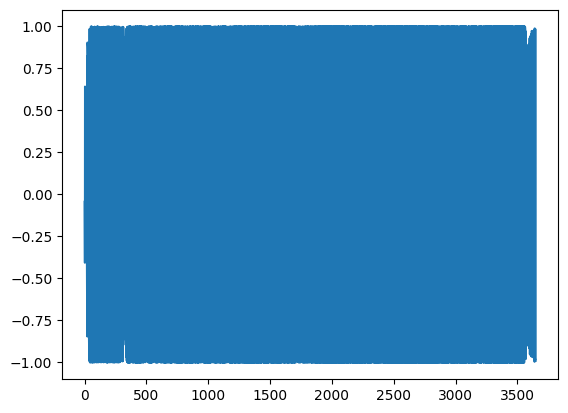

In [46]:
import sys

from tqdm import tqdm
import matplotlib.pyplot as plt
sys.path.insert(0, 'leaves-2025-07-03')
from gmlvq import gmlvq
import torch

lvq = gmlvq()
features = 3 # RGB channels
prototypes_per_class = 1
prototype_labels = [0, 1]
initial_prototypes = torch.randn(n_classes * prototypes_per_class, features)
mu = torch.randn(features)
std = torch.randn(features) + 0.1
lvq.initialize(features, initial_prototypes, prototype_labels, True, mu, std)

def trainImage(img, model, samples, label):
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_tensor = torch.from_numpy(img).float() / 255.0
    img_flat = img_tensor.reshape(-1, features)
    
    indices = torch.randperm(img_flat.shape[0])[:samples]
    sampled_pixels = img_flat[indices]
    losses = []
    for pixel in sampled_pixels:
        pixel = pixel.unsqueeze(0)        # shape: (1, features)
        lbl = torch.tensor([label])       # shape: (1,)
        losses.append(model.train(pixel, lbl))
    return torch.stack(losses).mean()

samples = 5
# n_minibatches = 250
losses = []
for img, label in tqdm(dataset):
    losses.append(trainImage(img, lvq, samples, label).data)

plt.plot(losses)
# plt.ylim(0,1)